In [4]:
import os
import re

import torch
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from statsmodels.stats.proportion import proportion_confint
import sys 
import analysis_utils
sys.path.append("../")

from checkpoint import CheckPoint
from datasets import LetterStringDataset, LetterStringDataLoader
import generate_data

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Batching by alphabet

In [41]:
perm_20 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm20_nep20.pt")
perm_40 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm40_nep20.pt")
perm_60 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm60_nep20.pt")
perm_80 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm80_nep20.pt")
perm_100 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm100_nep20.pt")
perm_140 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm140_nep20.pt")
perm_200 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm200_nep20.pt")
perm_400 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm400_nep20.pt")

all_training_runs = [perm_20, perm_40, perm_60, perm_80, perm_100, perm_140, perm_200, perm_400]

all_num_perm_alphs = [20,40,60,80,100,140,200,400]

In [42]:
# check that training alphabets have no overlap with new alphabets:
df20 = pd.read_csv("../data/all_transformations_study1_copy_perm20/train.csv")
df40 = pd.read_csv("../data/all_transformations_study1_copy_perm40/train.csv")
df60 = pd.read_csv("../data/all_transformations_study1_copy_perm60/train.csv")
df80 = pd.read_csv("../data/all_transformations_study1_copy_perm80/train.csv")
df100 = pd.read_csv("../data/all_transformations_study1_copy_perm100/train.csv")
df140 = pd.read_csv("../data/all_transformations_study1_copy_perm140/train.csv")
df200 = pd.read_csv("../data/all_transformations_study1_copy_perm200/train.csv")
df400 = pd.read_csv("../data/all_transformations_study1_copy_perm400/train.csv")

all_training_alphabets = set(
    list(df20.alphabet.unique()) + 
    list(df40.alphabet.unique()) + 
    list(df60.alphabet.unique()) + 
    list(df80.alphabet.unique()) +
    list(df100.alphabet.unique()) +
    list(df140.alphabet.unique()) +
    list(df200.alphabet.unique()) +
    list(df400.alphabet.unique())
    )

df_new_alphs = pd.read_csv("../data/all_transformations_study1_new_alphabets/test.csv")
# only overlapping alphabet should be the standard alphabet:
all_training_alphabets & set(df_new_alphs.alphabet.unique())

{'a b c d e f g h i j k l m n o p q r s t u v w x y z'}

In [43]:
levenshtein_distances_by_dataset = []
for training_alphabets in [df20, df40, df60, df80, df100, df140, df200, df400]:
    min_levenshtein_distances = []
    for new_alph in df_new_alphs.alphabet.unique():
        min_levenshtein_dist = 1_000_000 # initialize with arbitrarily large number
        for train_alph in training_alphabets.alphabet.unique():
            levenshtein_dist = nltk.edit_distance(train_alph, new_alph)
            if levenshtein_dist < min_levenshtein_dist:
                min_levenshtein_dist = levenshtein_dist
        min_levenshtein_distances.append(min_levenshtein_dist)
    levenshtein_distances_by_dataset.append({
        "mean": np.mean(min_levenshtein_distances),
        "sd": np.std(min_levenshtein_distances)
    })

In [ ]:
for perm_alphs, levenshtein_dist in zip(all_num_perm_alphs, levenshtein_distances_by_dataset):
    print(f"Training Dataset (with {perm_alphs} alphabets): Average minimum Levenshtein distance to new alphabets: {levenshtein_dist["mean"]:.2f} (sd: {levenshtein_dist["sd"]:.2f})")

Training Dataset (with 20 alphabets): Average minimum Levenshtein distance to new alphabets: 8.52 (sd: 6.64)
Training Dataset (with 40 alphabets): Average minimum Levenshtein distance to new alphabets: 8.38 (sd: 6.54)
Training Dataset (with 60 alphabets): Average minimum Levenshtein distance to new alphabets: 8.24 (sd: 6.61)
Training Dataset (with 80 alphabets): Average minimum Levenshtein distance to new alphabets: 8.19 (sd: 6.61)
Training Dataset (with 100 alphabets): Average minimum Levenshtein distance to new alphabets: 8.05 (sd: 6.48)
Training Dataset (with 140 alphabets): Average minimum Levenshtein distance to new alphabets: 7.86 (sd: 6.40)
Training Dataset (with 200 alphabets): Average minimum Levenshtein distance to new alphabets: 7.81 (sd: 6.43)
Training Dataset (with 400 alphabets): Average minimum Levenshtein distance to new alphabets: 7.71 (sd: 6.34)


In [ ]:
# predictions on new set of permuted alphabets
accs_new_alphabets = pd.DataFrame(columns=["batching_method", "num. seen alphabets in training", "seen transform.", "new transform."])
for i, cp in enumerate(all_training_runs):
    test_new_alph = cp.load_dataloaders(
        "../data/all_transformations_study1_new_alphabets", 
        use_datasets=["test"],
        verbose=False)[0]
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(test_new_alph, model, alternative_rule_errors=False)
    # exclude standard alphabet:
    pred = pred[pred["n_perm"]!= 0]
    test_acc_in = np.mean(pred[pred.distribution == "in"]["correct"])
    test_acc_out_of = np.mean(pred[pred.distribution == "out-of"]["correct"])
    accs_new_alphabets.loc[i,:] = [cp.train_config.batching_method, all_num_perm_alphs[i], test_acc_in, test_acc_out_of]
accs_new_alphabets["alphabets"] = "new"
accs_new_alphabets

Predicting: 370it [07:13,  1.17s/it]                         
Predicting: 370it [04:26,  1.39it/s]                         
Predicting: 370it [05:39,  1.09it/s]                         
Predicting: 370it [10:46,  1.75s/it]                         
Predicting: 370it [10:34,  1.71s/it]                         
Predicting: 370it [07:38,  1.24s/it]                         
Predicting: 370it [12:51,  2.09s/it]                         
Predicting: 370it [11:20,  1.84s/it]                         


,batching_method,num. seen alphabets in training,seen transform.,new transform.,alphabets
0,alphabet,20,0.3045,0.034993,new
1,alphabet,40,0.526952,0.062103,new
2,alphabet,60,0.567022,0.053259,new
3,alphabet,80,0.704087,0.071332,new
4,alphabet,100,0.729846,0.068448,new
5,alphabet,140,0.98076,0.185541,new
6,alphabet,200,0.998728,0.262257,new
7,alphabet,400,0.815869,0.040185,new


In [ ]:
# add validation set accuracies for the last episode (i.e., on the trained alphabets)
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["seen transform."] = round(np.max([x["in"] for x in train_run.val_acc_hist]), 3)
    data[i]["new transform."] = round(np.max([x["out-of"] for x in train_run.val_acc_hist]), 3)
df = pd.DataFrame(data)
df["num. seen alphabets in training"] = [20, 40, 60, 80, 100, 140, 200, 400]
df["alphabets"] = "seen"

In [ ]:
# Merge the two DataFrames on the 'perm. alphabets in training' column
df = df[["batching_method", "num. seen alphabets in training", "seen transform.", "new transform.", "alphabets"]]
all_accs = pd.concat([df, accs_new_alphabets])

In [ ]:
all_accs

,batching_method,num. seen alphabets in training,seen transform.,new transform.,alphabets
0,alphabet,20,0.9,0.1,seen
1,alphabet,40,0.949,0.126,seen
2,alphabet,60,0.936,0.093,seen
3,alphabet,80,0.947,0.138,seen
4,alphabet,100,0.931,0.104,seen
5,alphabet,140,1.0,0.238,seen
6,alphabet,200,1.0,0.271,seen
7,alphabet,400,0.809,0.05,seen
0,alphabet,20,0.3045,0.034993,new
1,alphabet,40,0.526952,0.062103,new


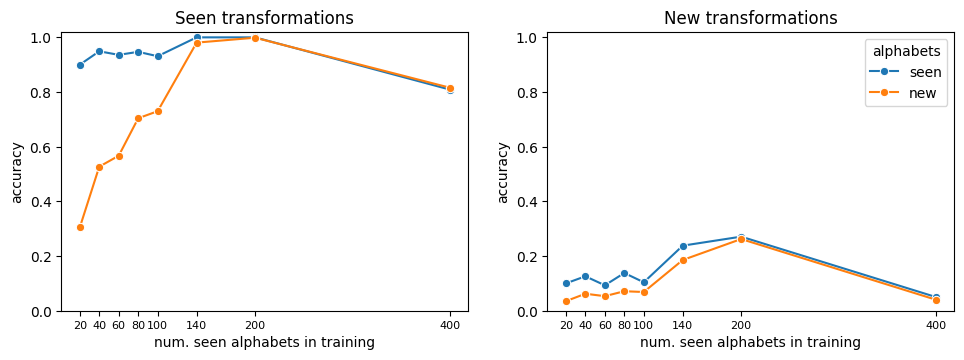

In [ ]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10,4))
_ = sns.lineplot(all_accs, 
                 x="num. seen alphabets in training", y="seen transform.", 
                 hue="alphabets", 
                 ax=ax[0], 
                 markers=True, 
                 marker="o")
_ = ax[0].set_ylim((0,1.02))
_ = ax[0].set_xticks([20, 40, 60, 80, 100, 140, 200, 400])
_ = ax[0].set_ylabel("accuracy")
_ = ax[0].legend().remove()
_ = ax[0].set_title("Seen transformations")
_ = sns.lineplot(all_accs, 
                    x="num. seen alphabets in training", y="new transform.", 
                    hue="alphabets", 
                    markers=True, 
                    marker="o",
                    ax=ax[1])
_ = ax[1].set_ylabel("accuracy")
_ = ax[1].set_ylim((0,1.02))
_ = ax[1].set_title("New transformations")

_ = fig.tight_layout(pad=2)
_ = fig.subplots_adjust(hspace=0.3)

ax[0].tick_params(axis='x', labelsize=8)
ax[1].tick_params(axis='x', labelsize=8)

In [ ]:
all_accs

,batching_method,num. seen alphabets in training,seen transform.,new transform.,alphabets
0,alphabet,20,0.9,0.1,seen
1,alphabet,40,0.949,0.126,seen
2,alphabet,60,0.936,0.093,seen
3,alphabet,80,0.947,0.138,seen
4,alphabet,100,0.931,0.104,seen
5,alphabet,140,1.0,0.238,seen
6,alphabet,200,1.0,0.271,seen
7,alphabet,400,0.809,0.05,seen
0,alphabet,20,0.3045,0.034993,new
1,alphabet,40,0.526952,0.062103,new


In [ ]:
# Pivot the DataFrame
wide_df = all_accs.pivot_table(
    index="num. seen alphabets in training",
    columns="alphabets",
    values=["seen transform.", "new transform."]
)

# Swap levels so that the higher level is 'alphabet_type'
wide_df = wide_df.swaplevel(axis=1).sort_index(axis=1, level=0)

# Optional: flatten the columns if you want
# wide_df.columns = [' '.join(col).strip() for col in wide_df.columns.values]
wide_df = wide_df.round(3)
# Result: wide_df has a multi-level column index as you described
print(wide_df.to_latex())

\begin{tabular}{lllll}
\toprule
alphabets & \multicolumn{2}{r}{new} & \multicolumn{2}{r}{seen} \\
 & new transform. & seen transform. & new transform. & seen transform. \\
num. seen alphabets in training &  &  &  &  \\
\midrule
20 & 0.034993 & 0.304500 & 0.100000 & 0.900000 \\
40 & 0.062103 & 0.526952 & 0.126000 & 0.949000 \\
60 & 0.053259 & 0.567022 & 0.093000 & 0.936000 \\
80 & 0.071332 & 0.704087 & 0.138000 & 0.947000 \\
100 & 0.068448 & 0.729846 & 0.104000 & 0.931000 \\
140 & 0.185541 & 0.980760 & 0.238000 & 1.000000 \\
200 & 0.262257 & 0.998728 & 0.271000 & 1.000000 \\
400 & 0.040185 & 0.815869 & 0.050000 & 0.809000 \\
\bottomrule
\end{tabular}



In [ ]:
wide_df

alphabets                                  new                           seen  \
                                new transform. seen transform. new transform.   
num. seen alphabets in training                                                 
20                                    0.034993          0.3045            0.1   
40                                    0.062103        0.526952          0.126   
60                                    0.053259        0.567022          0.093   
80                                    0.071332        0.704087          0.138   
100                                   0.068448        0.729846          0.104   
140                                   0.185541         0.98076          0.238   
200                                   0.262257        0.998728          0.271   
400                                   0.040185        0.815869           0.05   

alphabets                                        
                                seen transform.  
num. seen alphabets in training                  
20                                          0.9  
40                                        0.949  
60                                        0.936  
80                                        0.947  
100                                       0.931  
140                                         1.0  
200                                         1.0  
400                                       0.809

### Random Batching

In [ ]:
perm_20 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm20_nep20.pt")
perm_40 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm40_nep20.pt")
perm_60 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm60_nep20.pt")
perm_80 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm80_nep20.pt")
perm_100 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm100_nep20.pt")
perm_140 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm140_nep20.pt")
perm_200 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm200_nep20.pt")
perm_400 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchrand_dallstudy1_copy_perm400_nep20.pt")

all_training_runs_batch_random = [perm_20, perm_40, perm_60, perm_80, perm_100, perm_140, perm_200, perm_400]

In [ ]:
alphabets_in_training = [20, 40, 60, 80, 100, 140, 200, 400]
# predictions on new set of permuted alphabets
accs_new_alphabets_batch_random = pd.DataFrame(columns=["batching method", "num. seen alphabets in training", "seen transform.", "new transform."])
for i, cp in enumerate(all_training_runs_batch_random):
    test_new_alph = cp.load_dataloaders(
        "../data/all_transformations_study1_new_alphabets", 
        use_datasets=["test"],
        verbose=False)[0]
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(test_new_alph, model, alternative_rule_errors=False)
    # exclude standard alphabet:
    pred = pred[pred["n_perm"]!= 0]
    test_acc_in = round(np.mean(pred[pred.distribution == "in"]["correct"]), 3)
    test_acc_out_of = round(np.mean(pred[pred.distribution == "out-of"]["correct"]), 3)
    accs_new_alphabets_batch_random.loc[i,:] = [cp.train_config.batching_method, alphabets_in_training[i], test_acc_in, test_acc_out_of]
accs_new_alphabets_batch_random["alphabets"] = "new"
accs_new_alphabets_batch_random.round(3)

Predicting: 360it [04:18,  1.40it/s]                         
Predicting: 360it [07:07,  1.19s/it]                         
Predicting: 360it [13:08,  2.19s/it]                         
Predicting: 360it [15:05,  2.51s/it]                          
Predicting: 360it [09:50,  1.64s/it]                         
Predicting: 360it [06:30,  1.08s/it]                         
Predicting: 360it [09:58,  1.66s/it]                         
Predicting: 360it [11:29,  1.92s/it]                         


,batching method,num. seen alphabets in training,seen transform.,new transform.
0,random,20,0.362,0.039
1,random,40,0.48,0.057
2,random,60,0.621,0.064
3,random,80,0.702,0.065
4,random,100,0.969,0.252
5,random,140,0.765,0.047
6,random,200,0.995,0.096
7,random,400,0.999,0.109


In [ ]:
accs_new_alphabets_batch_random["alphabets"] = "new"

In [ ]:
# add validation set accuracies for the last episode (i.e., on the trained alphabets)
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs_batch_random]
for i, train_run in enumerate(all_training_runs_batch_random):
    data[i]["seen transform."] = round(np.max([x["in"] for x in train_run.val_acc_hist]), 3)
    data[i]["new transform."] = round(np.max([x["out-of"] for x in train_run.val_acc_hist]), 3)
    data[i]["batching method"] = train_run.train_config.batching_method
accs_seen_alphabets_batch_random = pd.DataFrame(data)
accs_seen_alphabets_batch_random["num. seen alphabets in training"] = [20, 40, 60, 80, 100, 140, 200, 400]
accs_seen_alphabets_batch_random = accs_seen_alphabets_batch_random[["batching method", "num. seen alphabets in training", "seen transform.","new transform."]]
accs_seen_alphabets_batch_random["alphabets"] = "seen"

In [ ]:
# Merge the two DataFrames on the 'perm. alphabets in training' column
all_accs_batchrand = pd.concat([accs_seen_alphabets_batch_random, accs_new_alphabets_batch_random])

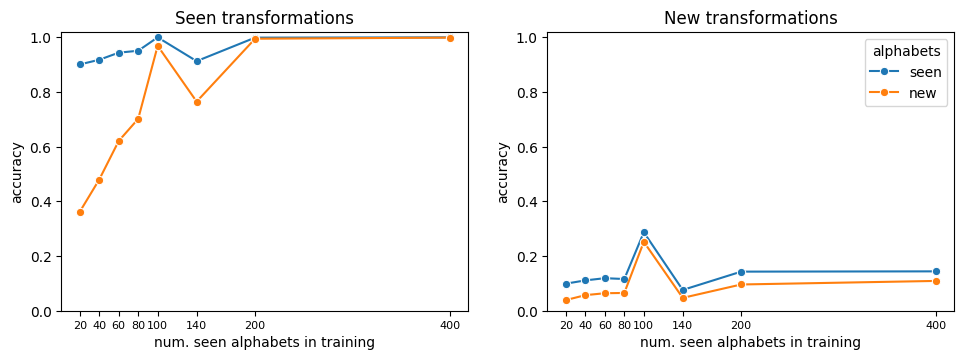

In [ ]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10,4))
_ = sns.lineplot(all_accs_batchrand, 
                 x="num. seen alphabets in training", y="seen transform.", 
                 hue="alphabets", 
                 ax=ax[0], 
                 markers=True, 
                 marker="o")
_ = ax[0].set_ylim((0,1.02))
_ = ax[0].set_xticks([20, 40, 60, 80, 100, 140, 200, 400])
_ = ax[0].set_ylabel("accuracy")
_ = ax[0].legend().remove()
_ = ax[0].set_title("Seen transformations")
_ = sns.lineplot(all_accs_batchrand, 
                    x="num. seen alphabets in training", y="new transform.", 
                    hue="alphabets", 
                    markers=True, 
                    marker="o",
                    ax=ax[1])
_ = ax[1].set_ylabel("accuracy")
_ = ax[1].set_ylim((0,1.02))
_ = ax[1].legend(title="alphabets", loc='upper right')
_ = ax[1].set_title("New transformations")

_ = fig.tight_layout(pad=2)
_ = fig.subplots_adjust(hspace=0.3)
ax[0].tick_params(axis='x', labelsize=8)
ax[1].tick_params(axis='x', labelsize=8)

In [ ]:
all_accs["batching_method"] = "random"
all_accs

,accuracy in-dist,accuracy out-of-dist,perm. alphabets in training,new_alphabets,batching_method
0,0.901,0.099,20,False,random
1,0.918,0.111,40,False,random
2,0.944,0.119,60,False,random
3,0.951,0.116,80,False,random
4,1.0,0.287,100,False,random
5,0.913,0.076,140,False,random
6,0.999,0.143,200,False,random
7,1.0,0.144,400,False,random
0,0.362061,0.038646,20,True,random
1,0.479727,0.057104,40,True,random


In [ ]:
# Create a new column for the higher-level index
all_accs['alphabet_type'] = all_accs['new_alphabets'].map({False: 'seen alphabets', True: 'new alphabets'})

# Pivot the DataFrame
wide_df = all_accs.pivot_table(
    index="perm. alphabets in training",
    columns="alphabet_type",
    values=["accuracy in-dist", "accuracy out-of-dist"]
)

# Swap levels so that the higher level is 'alphabet_type'
wide_df = wide_df.swaplevel(axis=1).sort_index(axis=1, level=0)

# Optional: flatten the columns if you want
# wide_df.columns = [' '.join(col).strip() for col in wide_df.columns.values]
wide_df = wide_df.round(3)
# Result: wide_df has a multi-level column index as you described
print(wide_df.to_latex())

\begin{tabular}{lllll}
\toprule
alphabet_type & \multicolumn{2}{r}{new alphabets} & \multicolumn{2}{r}{seen alphabets} \\
 & accuracy in-dist & accuracy out-of-dist & accuracy in-dist & accuracy out-of-dist \\
perm. alphabets in training &  &  &  &  \\
\midrule
20 & 0.362061 & 0.038646 & 0.901000 & 0.099000 \\
40 & 0.479727 & 0.057104 & 0.918000 & 0.111000 \\
60 & 0.621084 & 0.064218 & 0.944000 & 0.119000 \\
80 & 0.702337 & 0.065372 & 0.951000 & 0.116000 \\
100 & 0.969152 & 0.252067 & 1.000000 & 0.287000 \\
140 & 0.765304 & 0.047299 & 0.913000 & 0.076000 \\
200 & 0.994594 & 0.096328 & 0.999000 & 0.143000 \\
400 & 0.999205 & 0.108633 & 1.000000 & 0.144000 \\
\bottomrule
\end{tabular}



# Replications

## Plots

In [2]:
def bootstrapped_confint(arr, n_samples:int = 10_000, alpha:float=0.05):
    # sample with replacement n_samples times and take the mean of each sample:
    samples = np.array([np.mean(np.random.choice(arr, size=len(arr), replace=True)) for _ in range(n_samples)])
    # sort means in ascending order:
    samples.sort()
    # get bootstrapped confidence interval boundaries:
    confint_low = samples[int(n_samples * (alpha / 2))]
    confint_upp = samples[int(n_samples * (1 - alpha / 2))]
    return confint_low, confint_upp

In [8]:
pattern = r'perm(\d+)_'
dir_path = "../models/num_permuted_alphabets"
training_runs = os.listdir(dir_path)
all_alph_runs = []
all_rand_runs = []
for run in training_runs:
    if "alph" in run:
        cp = CheckPoint.from_pt("/".join([dir_path,run]))
        perm = re.search(pattern, run)
        cp.num_perm_alphs = int(perm.group(1))
        all_alph_runs.append(cp)
    else:
        cp = CheckPoint.from_pt("/".join([dir_path,run]))
        perm = re.search(pattern, run)
        cp.num_perm_alphs = int(perm.group(1))
        all_rand_runs.append(cp)

In [9]:
all_training_runs = all_alph_runs
# add validation set accuracies for the last episode (i.e., on the trained alphabets)
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["seen transform."] = round([x["in"] for x in train_run.val_acc_hist][-1], 3)
    data[i]["new transform."] = round([x["out-of"] for x in train_run.val_acc_hist][-1], 3)
    data[i]["num. seen alphabets in training"] = train_run.num_perm_alphs
df = pd.DataFrame(data)
df["alphabets"] = "seen"

# predictions on new set of permuted alphabets
accs_new_alphabets = pd.DataFrame(columns=["batching_method", "num. seen alphabets in training", "seen transform.", "new transform."])
test_new_alph = LetterStringDataLoader(
    mode="test", 
    data_dir="../data/all_transformations_study1_new_alphabets",
    batch_size=2000
)
for i, cp in enumerate(all_training_runs):
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(test_new_alph, model, alternative_rule_errors=False)
    # exclude standard alphabet:
    pred = pred[pred["n_perm"]!= 0]
    test_acc_in = np.mean(pred[pred.distribution == "in"]["correct"])
    test_acc_out_of = np.mean(pred[pred.distribution == "out-of"]["correct"])
    accs_new_alphabets.loc[i,:] = [cp.train_config.batching_method, cp.num_perm_alphs, test_acc_in, test_acc_out_of]
accs_new_alphabets["alphabets"] = "new"

all_accs_alph = pd.concat([
    df[["batching_method", "num. seen alphabets in training", "seen transform.", "new transform.", "alphabets"]],
    accs_new_alphabets])

Generating predictions: 6it [02:26, 24.49s/it]                       
Generating predictions: 6it [02:35, 25.99s/it]                       
Generating predictions: 6it [02:40, 26.82s/it]                       
Generating predictions: 6it [02:41, 26.95s/it]                       
Generating predictions: 6it [02:34, 25.75s/it]                       
Generating predictions: 6it [02:33, 25.65s/it]                       
Generating predictions: 6it [02:34, 25.69s/it]                       
Generating predictions: 6it [02:32, 25.35s/it]                       
Generating predictions: 6it [02:36, 26.08s/it]                       
Generating predictions: 6it [02:01, 20.29s/it]                       
Generating predictions: 6it [02:00, 20.16s/it]                       
Generating predictions: 6it [02:14, 22.39s/it]                       
Generating predictions: 6it [02:23, 23.97s/it]                       
Generating predictions: 6it [01:55, 19.22s/it]                       
Generating predictio

Batching Method = alphabet


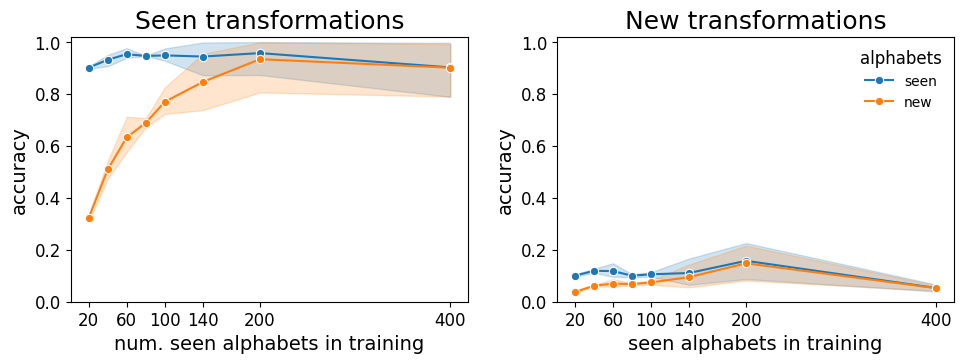

In [8]:
# Figure 4 (lower part)
print("Batching Method = alphabet")
plt.style.use("./figures_stylesheet.mplstyle")
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10,4))
_ = sns.lineplot(all_accs_alph, 
                 x="num. seen alphabets in training", y="seen transform.", 
                 hue="alphabets", 
                 ax=ax[0], 
                 markers=True, 
                 marker="o")
_ = ax[0].set_ylim((0,1.02))
_ = ax[1].set_xlabel("seen alphabets in training")
_ = ax[0].set_xticks([20, 60, 100, 140, 200, 400])
_ = ax[0].set_ylabel("accuracy")
_ = ax[0].legend().remove()
_ = ax[0].set_title("Seen transformations")
_ = sns.lineplot(all_accs_alph, 
                x="num. seen alphabets in training", y="new transform.",   
                hue="alphabets", 
                ax=ax[1],
                markers=True, 
                marker="o",
                errorbar=bootstrapped_confint)
_ = ax[1].set_xlabel("seen alphabets in training")
_ = ax[1].set_ylabel("accuracy")
_ = ax[1].set_ylim((0,1.02))
_ = ax[1].set_title("New transformations")

_ = fig.tight_layout(pad=2)

In [13]:
all_training_runs = all_rand_runs
# add validation set accuracies for the last episode (i.e., on the trained alphabets)
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["seen transform."] = round([x["in"] for x in train_run.val_acc_hist][-1], 3)
    data[i]["new transform."] = round([x["out-of"] for x in train_run.val_acc_hist][-1], 3)
    data[i]["num. seen alphabets in training"] = train_run.num_perm_alphs
df = pd.DataFrame(data)
df["alphabets"] = "seen"

# predictions on new set of permuted alphabets
accs_new_alphabets = pd.DataFrame(columns=["batching_method", "num. seen alphabets in training", "seen transform.", "new transform."])
for i, cp in enumerate(all_training_runs):
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(test_new_alph, model, alternative_rule_errors=False)
    # exclude standard alphabet:
    pred = pred[pred["n_perm"]!= 0]
    test_acc_in = np.mean(pred[pred.distribution == "in"]["correct"])
    test_acc_out_of = np.mean(pred[pred.distribution == "out-of"]["correct"])
    accs_new_alphabets.loc[i,:] = [cp.train_config.batching_method, cp.num_perm_alphs, test_acc_in, test_acc_out_of]
accs_new_alphabets["alphabets"] = "new"

all_accs_rand = pd.concat([
    df[["batching_method", "num. seen alphabets in training", "seen transform.", "new transform.", "alphabets"]],
    accs_new_alphabets])

Generating predictions: 6it [01:30, 15.02s/it]                       
Generating predictions: 6it [02:17, 22.86s/it]                       
Generating predictions: 6it [01:48, 18.11s/it]                       
Generating predictions: 6it [02:18, 23.13s/it]                       
Generating predictions: 6it [02:17, 22.92s/it]                       
Generating predictions: 6it [02:01, 20.24s/it]                       
Generating predictions: 6it [03:11, 31.94s/it]                       
Generating predictions: 6it [02:41, 26.87s/it]                       
Generating predictions: 6it [02:41, 26.90s/it]                       
Generating predictions: 6it [02:32, 25.43s/it]                       
Generating predictions: 6it [02:48, 28.06s/it]                       
Generating predictions: 6it [03:14, 32.37s/it]                       
Generating predictions: 6it [02:42, 27.02s/it]                       
Generating predictions: 6it [02:53, 29.00s/it]                       
Generating predictio

Batching Method = random


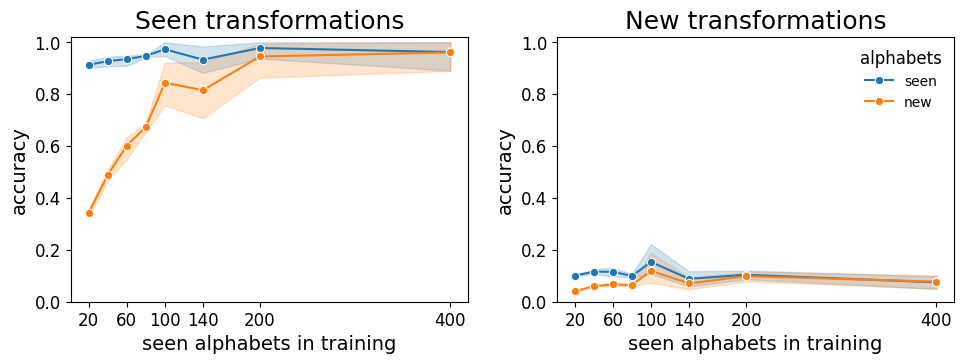

In [7]:
# Figure 4 (upper part)
print("Batching Method = random")
plt.style.use("./figures_stylesheet.mplstyle")
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10,4))
_ = sns.lineplot(all_accs_rand, 
                 x="num. seen alphabets in training", y="seen transform.", 
                 hue="alphabets", 
                 ax=ax[0], 
                 markers=True, 
                 marker="o")
_ = ax[0].set_ylim((0,1.02))
_ = ax[0].set_xticks([20, 60, 100, 140, 200, 400])
_ = ax[0].set_xlabel("seen alphabets in training")
_ = ax[0].set_ylabel("accuracy")
_ = ax[0].legend().remove()
_ = ax[0].set_title("Seen transformations")
_ = sns.lineplot(all_accs_rand, 
                x="num. seen alphabets in training", y="new transform.",   
                hue="alphabets", 
                ax=ax[1],
                markers=True, 
                marker="o",
                errorbar=bootstrapped_confint)
_ = ax[1].set_xlabel("seen alphabets in training")
_ = ax[1].set_ylabel("accuracy")
_ = ax[1].set_ylim((0,1.02))
_ = ax[1].set_title("New transformations")

_ = fig.tight_layout(pad=2)

In [ ]:
all_accs_alph.to_csv("rep5_old_new_alphabets_batchalph.csv", index=False)
all_accs_rand.to_csv("rep5_old_new_alphabets_batchrand.csv", index=False)

## Binomial Confidence intervals

In [5]:
all_accs_alph = pd.read_csv("rep5_old_new_alphabets_batchalph.csv")
all_accs_rand = pd.read_csv("rep5_old_new_alphabets_batchrand.csv")

In [102]:
# create dataframe with columns
alphabets = ["seen", "new"]
transformations = ["seen", "new"]

# Create MultiIndex for columns
columns = pd.MultiIndex.from_product([alphabets, transformations], names=["alphabets", "transformations"])

# Example data: 8 rows (for 8 training sizes), 4 columns (2x2)
data = np.random.rand(8, 4)

train_alph_levels = [20, 40, 60, 80, 100, 140, 200, 400]
# Create the DataFrame
df_batch_rand = pd.DataFrame("NA", index=train_alph_levels, columns=columns)
df_batch_rand.index.name = "num. seen alphabets in training"
df_batch_alph = df_batch_rand.copy(deep=True)

In [109]:
bootstrapped_samples = 10_000

for train_alphs in train_alph_levels:
    df_train_alphs = all_accs_alph[all_accs_alph["num. seen alphabets in training"]==train_alphs]
    for alphs in ["seen", "new"]:
        for transforms in ["seen", "new"]:
            accs = df_train_alphs[df_train_alphs["alphabets"]==alphs][f"{transforms} transform."]
            mean_acc = np.mean(accs)
            # resample:
            acc_samples = np.array([np.mean(np.random.choice(accs, size=len(accs), replace=True)) for _ in range(bootstrapped_samples)])
            # sort ascending
            acc_samples.sort()
            # get bootstrapped confidence interval boundaries:
            ci_low = acc_samples[int(bootstrapped_samples * 0.025)]
            ci_upp = acc_samples[int(bootstrapped_samples * 0.975)]
            # multiply by 100 to convert to % for table
            df_batch_alph.loc[train_alphs, (alphs, transforms)] = f"{mean_acc*100:.1f} [{ci_low*100:.1f}, {ci_upp*100:.1f}]"
df_batch_alph

alphabets                                      seen                     \
transformations                                seen                new   
num. seen alphabets in training                                          
20                                90.2 [89.7, 90.7]   10.0 [9.6, 10.5]   
40                                93.2 [90.8, 95.1]  11.9 [11.2, 12.7]   
60                                95.3 [93.9, 97.6]   11.8 [9.6, 14.8]   
80                                94.7 [94.6, 94.7]   10.0 [9.4, 10.6]   
100                               94.9 [92.8, 97.5]   10.6 [9.6, 11.4]   
140                               94.4 [87.2, 99.9]   11.1 [6.5, 16.6]   
200                              95.8 [87.3, 100.0]   15.8 [8.7, 22.6]   
400                               90.2 [79.1, 99.7]     5.3 [4.0, 6.6]   

alphabets                                      new                    
transformations                               seen               new  
num. seen alphabets in training                                       
20                               32.4 [31.4, 33.4]    3.8 [3.5, 4.1]  
40                               51.0 [47.4, 54.3]    6.1 [5.8, 6.5]  
60                               63.3 [57.7, 71.4]    7.0 [5.9, 8.7]  
80                               68.9 [67.2, 70.5]    6.8 [6.2, 7.2]  
100                              77.0 [72.6, 82.6]    7.4 [6.6, 8.2]  
140                              84.7 [72.4, 95.1]   9.5 [5.5, 14.3]  
200                              93.4 [80.6, 99.9]  14.8 [8.1, 21.6]  
400                              90.1 [79.0, 99.4]    5.2 [4.2, 6.2]

In [113]:
for train_alphs in train_alph_levels:
    df_train_alphs = all_accs_rand[all_accs_rand["num. seen alphabets in training"]==train_alphs]
    for alphs in ["seen", "new"]:
        for transforms in ["seen", "new"]:
            accs = df_train_alphs[df_train_alphs["alphabets"]==alphs][f"{transforms} transform."]
            mean_acc = np.mean(accs)
            # resample with replacement and calculate means:
            acc_samples = np.array([np.mean(np.random.choice(accs, size=len(accs), replace=True)) for _ in range(bootstrapped_samples)])
            # sort ascending
            acc_samples.sort()
            # get bootstrapped confidence interval boundaries:
            ci_low = acc_samples[int(bootstrapped_samples * 0.025)]
            ci_upp = acc_samples[int(bootstrapped_samples * 0.975)]
            # multiply by 100 to convert to % for table
            df_batch_rand.loc[train_alphs, (alphs, transforms)] = f"{mean_acc*100:.1f} [{ci_low*100:.1f}, {ci_upp*100:.1f}]"
df_batch_rand

alphabets                                      seen                     \
transformations                                seen                new   
num. seen alphabets in training                                          
20                                91.2 [90.0, 92.8]   10.1 [9.8, 10.3]   
40                                92.7 [90.6, 94.4]  11.5 [10.6, 12.4]   
60                                93.4 [90.8, 94.9]   11.5 [9.7, 13.2]   
80                                94.7 [94.2, 95.0]    9.9 [9.2, 10.6]   
100                               97.2 [94.5, 99.9]  15.3 [10.7, 22.2]   
140                               93.2 [88.2, 98.3]    8.8 [5.9, 11.7]   
200                               97.7 [93.7, 99.9]   10.4 [8.7, 12.0]   
400                              96.2 [88.9, 100.0]     7.5 [4.9, 9.8]   

alphabets                                      new                    
transformations                               seen               new  
num. seen alphabets in training                                       
20                               34.2 [32.7, 35.7]    4.0 [3.9, 4.0]  
40                               48.8 [46.5, 50.8]    6.0 [5.8, 6.3]  
60                               60.1 [54.9, 63.3]    6.7 [5.9, 7.2]  
80                               67.2 [65.3, 69.0]    6.4 [6.1, 6.7]  
100                              84.3 [75.7, 93.0]  11.9 [7.3, 18.8]  
140                              81.5 [70.7, 93.2]    7.0 [4.8, 9.3]  
200                              94.5 [86.3, 99.4]   9.8 [7.9, 11.7]  
400                              96.0 [88.7, 99.9]   7.7 [5.1, 10.2]

In [110]:
# Add batching_method as a new index level and concatenate
df_batch_rand_with_index = pd.concat(
    {"random": df_batch_rand}, names=["batching_method"]
)
df_batch_alph_with_index = pd.concat(
    {"alphabet": df_batch_alph}, names=["batching_method"]
)

# Combine both DataFrames
df_combined = pd.concat([df_batch_rand_with_index, df_batch_alph_with_index])

# Now df_combined has a MultiIndex with batching_method and num. seen alphabets in training
df_combined

alphabets                                                      seen  \
transformations                                                seen   
batching_method num. seen alphabets in training                       
random          20                                91.2 [90.0, 92.8]   
                40                                92.7 [90.6, 94.4]   
                60                                93.4 [90.8, 94.9]   
                80                                94.7 [94.2, 95.0]   
                100                               97.2 [94.5, 99.9]   
                140                               93.2 [88.2, 98.3]   
                200                               97.7 [93.6, 99.9]   
                400                              96.2 [88.9, 100.0]   
alphabet        20                                90.2 [89.7, 90.7]   
                40                                93.2 [90.8, 95.1]   
                60                                95.3 [93.9, 97.6]   
                80                                94.7 [94.6, 94.7]   
                100                               94.9 [92.8, 97.5]   
                140                               94.4 [87.2, 99.9]   
                200                              95.8 [87.3, 100.0]   
                400                               90.2 [79.1, 99.7]   

alphabets                                                           \
transformations                                                new   
batching_method num. seen alphabets in training                      
random          20                                10.1 [9.8, 10.3]   
                40                               11.5 [10.6, 12.4]   
                60                                11.5 [9.7, 13.0]   
                80                                 9.9 [9.2, 10.6]   
                100                              15.3 [10.7, 22.2]   
                140                                8.8 [5.9, 11.7]   
                200                               10.4 [8.6, 12.0]   
                400                                 7.5 [4.9, 9.8]   
alphabet        20                                10.0 [9.6, 10.5]   
                40                               11.9 [11.2, 12.7]   
                60                                11.8 [9.6, 14.8]   
                80                                10.0 [9.4, 10.6]   
                100                               10.6 [9.6, 11.4]   
                140                               11.1 [6.5, 16.6]   
                200                               15.8 [8.7, 22.6]   
                400                                 5.3 [4.0, 6.6]   

alphabets                                                      new  \
transformations                                               seen   
batching_method num. seen alphabets in training                      
random          20                               34.2 [32.7, 35.7]   
                40                               48.8 [46.5, 50.8]   
                60                               60.1 [54.9, 63.3]   
                80                               67.2 [65.3, 69.0]   
                100                              84.3 [75.9, 93.0]   
                140                              81.5 [70.7, 93.2]   
                200                              94.5 [86.3, 99.4]   
                400                              96.0 [88.7, 99.9]   
alphabet        20                               32.4 [31.4, 33.4]   
                40                               51.0 [47.4, 54.3]   
                60                               63.3 [57.7, 71.4]   
                80                               68.9 [67.2, 70.5]   
                100                              77.0 [72.6, 82.6]   
                140                              84.7 [72.4, 95.1]   
                200                              93.4 [80.6, 99.9]   
                400                              90.1 [79.0

In [ ]:
# Table 2 (Appendix):
print(df_combined.to_latex())

\begin{tabular}{llllll}
\toprule
 & alphabets & \multicolumn{2}{r}{seen} & \multicolumn{2}{r}{new} \\
 & transformations & seen & new & seen & new \\
batching_method & num. seen alphabets in training &  &  &  &  \\
\midrule
\multirow[t]{8}{*}{random} & 20 & 91.2 [90.0, 92.8] & 10.1 [9.8, 10.3] & 34.2 [32.7, 35.7] & 4.0 [3.9, 4.0] \\
 & 40 & 92.7 [90.6, 94.4] & 11.5 [10.6, 12.4] & 48.8 [46.5, 50.8] & 6.0 [5.8, 6.3] \\
 & 60 & 93.4 [90.8, 94.9] & 11.5 [9.7, 13.0] & 60.1 [54.9, 63.3] & 6.7 [5.9, 7.2] \\
 & 80 & 94.7 [94.2, 95.0] & 9.9 [9.2, 10.6] & 67.2 [65.3, 69.0] & 6.4 [6.1, 6.7] \\
 & 100 & 97.2 [94.5, 99.9] & 15.3 [10.7, 22.2] & 84.3 [75.9, 93.0] & 11.9 [7.3, 18.8] \\
 & 140 & 93.2 [88.2, 98.3] & 8.8 [5.9, 11.7] & 81.5 [70.7, 93.2] & 7.0 [4.8, 9.3] \\
 & 200 & 97.7 [93.6, 99.9] & 10.4 [8.6, 12.0] & 94.5 [86.3, 99.4] & 9.8 [7.8, 11.6] \\
 & 400 & 96.2 [88.9, 100.0] & 7.5 [4.9, 9.8] & 96.0 [88.7, 99.9] & 7.7 [5.1, 10.2] \\
\cline{1-6}
\multirow[t]{8}{*}{alphabet} & 20 & 90.2 [89.7, 90.

## Plot Accuracies New (compositional) transformations best model

In [71]:
all_accs_alph.sort_values("new transform.", ascending=False)

,batching_method,num. seen alphabets in training,seen transform.,new transform.,alphabets
10,alphabet,200,1.000000,0.271000,seen
50,alphabet,200,0.998728,0.262257,new
12,alphabet,200,1.000000,0.215000,seen
5,alphabet,140,1.000000,0.215000,seen
52,alphabet,200,0.999682,0.194963,new
...,...,...,...,...,...
51,alphabet,200,0.679281,0.036531,new
58,alphabet,20,0.328033,0.036147,new
57,alphabet,20,0.329623,0.035186,new
55,alphabet,20,0.304500,0.034993,new


In [142]:
best_cp = all_alph_runs[10]
print(best_cp)

### MLC Config

```
hidden_size: 128
input_size: 30
output_size: 30
PAD_idx_input: 28
PAD_idx_output: 28
nlayers_encoder: 3
nlayers_decoder: 3
nhead: 8
dropout_p: 0.1
ff_mult: 4
activation: gelu
```

### Train Config

```
filename_model: MLC_batchalph_dallstudy1_copy_perm200_nep20.pt
dir_model: models
dir_data: data/all_transformations_study1_copy_perm200
batch_size: 32
batching_method: alphabet
query_first: False
nepochs: 20
lr: 0.001
lr_end_factor: 0.05
lr_warmup: True
save_best: True
save_best_skip: 0.2
```

### Training Run

Trained for 18 out of 20 epochs.

Best Val. Loss: 0.604

Highest Val. Accuracy: 0.717, in-distribution: 1.000, out-of-distribution: 0.271


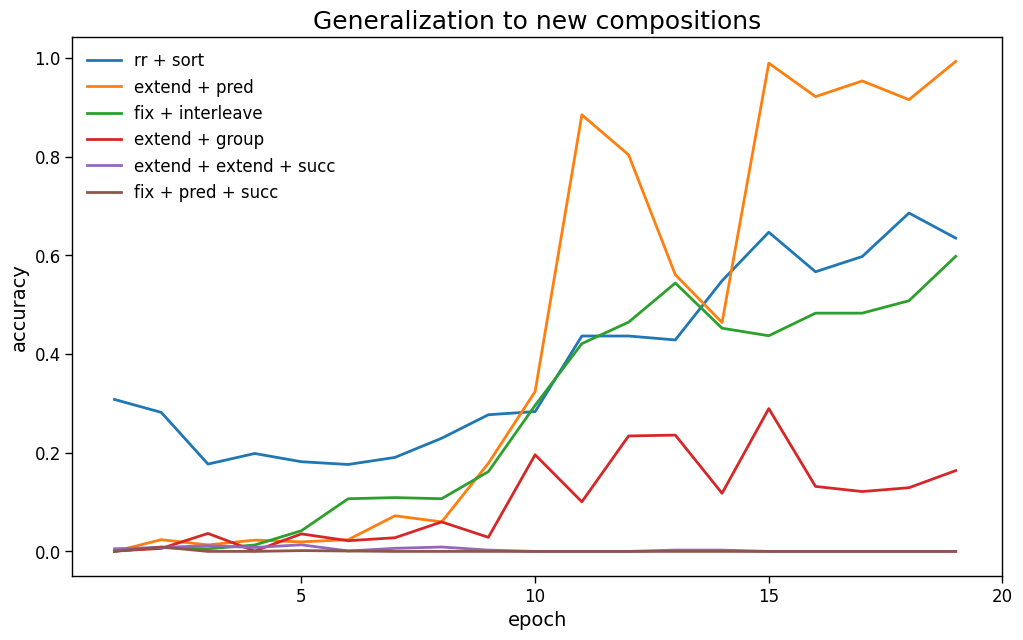

In [ ]:
# Figure 5:
val_acc = pd.DataFrame(best_cp.val_acc_hist)
val_acc_by_gen = pd.melt(val_acc, id_vars=['epoch'], value_vars=[generate_data.ALL_TRANSFORMATIONS[i]["transformation"] for i in range(1,20)], var_name="transformation", value_name="accuracy")
trans2idx = {trans["transformation"]: idx for idx, trans in generate_data.ALL_TRANSFORMATIONS.items()}
val_acc_by_gen["generalization"] = val_acc_by_gen.transformation.apply(
        lambda x: generate_data.ALL_TRANSFORMATIONS[trans2idx[str(x)]]["generalization_type"]
)

generalization_descriptions = {
    0: "in training tranformations",
    2: "new compositions",
    3: "completely new rules"
}
val_acc_by_gen["transformation"] = val_acc_by_gen["transformation"].apply(lambda x: x.replace("_", " + "))
# fig, ax = plt.subplots(3, 1, figsize=(8,16))
# for i, gen_type in enumerate([0,2,3]):
_ = plt.figure(figsize=(12,7))
_ = sns.lineplot(data=val_acc_by_gen[val_acc_by_gen.generalization==2], x="epoch", y="accuracy", hue="transformation")
_ = plt.title(f"Generalization to {generalization_descriptions[2]}")
_ = plt.xticks([5, 10, 15, 20])
_ = plt.legend(loc='upper left', fontsize=12)

## Assess Predictions Best Model

In [86]:
# take best model and extract predictions for new rules:
best_model = all_rand_runs[0].load_model()
pred = analysis_utils.predict_dataset(test_new_alph, best_model, alternative_rule_errors=False)

Loading model that has completed 20 of 20 epochs
	batch size: 32
	number of steps: 229,520
	best val loss achieved: 0.6512
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout


Generating predictions: 6it [04:24, 44.07s/it]                       


### Export Predictions of Best Model
- Errors were manually graded after exporting predictions

In [ ]:
false_pred_samples = pred[(~pred.correct) & (pred.distribution=="out-of")].groupby("transformation").sample(5, replace=True)
false_pred_samples[
        ["transformation", "n_perm", "alphabet", "study", "problem", "pred"]
    ].to_csv("false_predictions_new_trans_best_model.csv", index=False)